<a href="https://colab.research.google.com/github/edwardaohewitt2000-sudo/Mathematical-Modelling-Portfolio/blob/main/Boiling_crisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

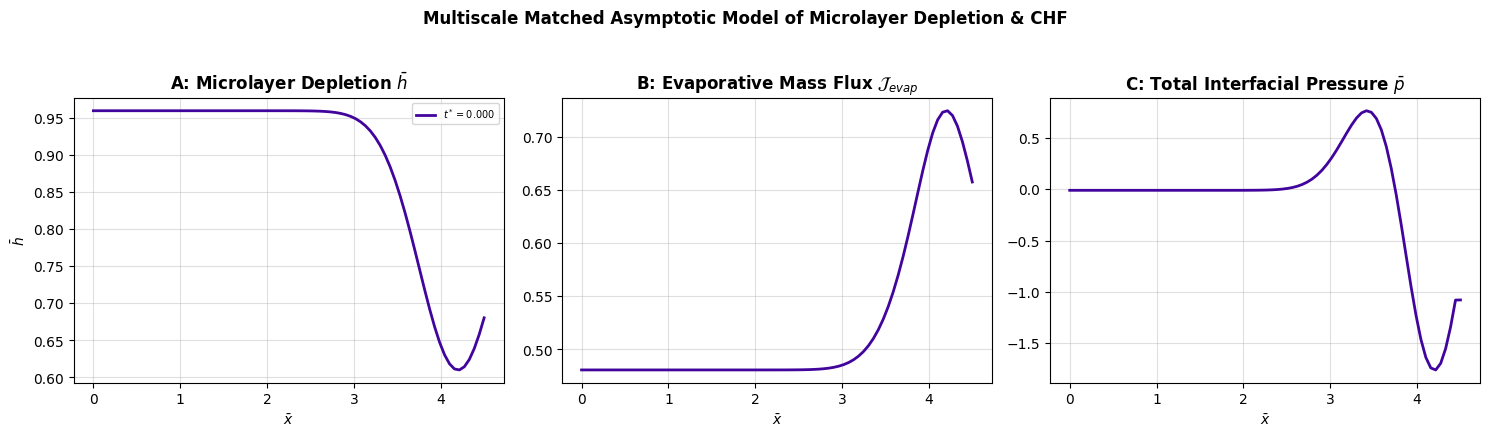

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def solve_3scale_chf_robust(
    Nx=80,                # Spatial nodes
    L_x=4.5,              # Non-dimensional domain size
    t_final=0.03,         # Simulation run time
    E=0.5,                # Evaporative number
    K_star=0.08,          # Kinetic thermal resistance
    R_recoil=0.04         # Recoil parameter
):
    # Spatial discretization
    x = np.linspace(0, L_x, Nx)
    dx = x[1] - x[0]
    H_e = 0.05  # Physical adsorbed film floor limit

    # Initial smooth microlayer profile
    h0 = 0.96 - 0.35 * np.exp(-((x - 4.2)**2) / 0.4)
    h0 = np.maximum(h0, H_e)

    # Stiff PDE Right-Hand Side Evaluation
    def rhs(t, h_vec):
        h_curr = np.maximum(h_vec, H_e)

        # 1. Interfacial Curvature
        d2h = np.zeros(Nx)
        d2h[1:-1] = (h_curr[2:] - 2*h_curr[1:-1] + h_curr[:-2]) / (dx**2)
        d2h[0] = d2h[1]; d2h[-1] = d2h[-2]

        # 2. Local Evaporation & Vapor Recoil Pressure
        j_evap = E / (h_curr + K_star)
        p = -d2h - R_recoil * (j_evap**2)

        # 3. Interfacial Pressure Gradient
        dp_dx = np.zeros(Nx)
        dp_dx[1:-1] = (p[2:] - p[:-2]) / (2 * dx)
        dp_dx[0] = (p[1] - p[0]) / dx
        dp_dx[-1] = (p[-1] - p[-2]) / dx

        # 4. Viscous Hydrodynamic Mass Flux
        flux = (h_curr**3 / 3.0) * dp_dx
        div_flux = np.zeros(Nx)
        div_flux[1:-1] = (flux[2:] - flux[:-2]) / (2 * dx)

        # 5. Mass Conservation Time Derivative
        dh_dt = -div_flux - j_evap
        dh_dt[0] = dh_dt[1]
        dh_dt[-1] = -j_evap[-1]

        return dh_dt

    # Solve via Radau / BDF stiff adaptive integrator
    t_eval = np.linspace(0, t_final, 5)
    sol = solve_ivp(rhs, (0, t_final), h0, method='Radau', t_eval=t_eval, rtol=1e-4, atol=1e-6)

    # Extract profiles
    h_hist = [sol.y[:, i] for i in range(len(sol.t))]
    j_hist = [E / (sol.y[:, i] + K_star) for i in range(len(sol.t))]

    p_hist = []
    for i in range(len(sol.t)):
        h_c = sol.y[:, i]
        d2h = np.zeros(Nx)
        d2h[1:-1] = (h_c[2:] - 2*h_c[1:-1] + h_c[:-2]) / (dx**2)
        d2h[0] = d2h[1]; d2h[-1] = d2h[-2]
        p_val = -d2h - R_recoil * (E / (h_c + K_star))**2
        p_hist.append(p_val)

    return x, sol.t, h_hist, j_hist, p_hist

# Run robust solver
x_bar, times, h_hist, j_hist, p_hist = solve_3scale_chf_robust()

# Render visual dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=100)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(times)))

for i in range(len(times)):
    axes[0].plot(x_bar, h_hist[i], label=f'$t^*={times[i]:.3f}$', color=colors[i], lw=2)
    axes[1].plot(x_bar, j_hist[i], color=colors[i], lw=2)
    axes[2].plot(x_bar, p_hist[i], color=colors[i], lw=2)

axes[0].set_title("A: Microlayer Depletion $\\bar{h}$", fontweight='bold')
axes[0].set_xlabel("$\\bar{x}$"); axes[0].set_ylabel("$\\bar{h}$")
axes[0].grid(True, alpha=0.4); axes[0].legend(fontsize=7)

axes[1].set_title("B: Evaporative Mass Flux $\\mathcal{J}_{evap}$", fontweight='bold')
axes[1].set_xlabel("$\\bar{x}$"); axes[1].grid(True, alpha=0.4)

axes[2].set_title("C: Total Interfacial Pressure $\\bar{p}$", fontweight='bold')
axes[2].set_xlabel("$\\bar{x}$"); axes[2].grid(True, alpha=0.4)

plt.suptitle("Multiscale Matched Asymptotic Model of Microlayer Depletion & CHF", fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()